# 9. PyTorch Tutorial 09 - Dataset and DataLoader - Batch Training

In [1]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math

## Making the dataset a specific object with particular attributesa and methods

In [2]:
# Create a class of objects
class WineDataset(Dataset):

    def __init__(self):
        # Initialize data, download, etc.
        # read with numpy or pandas
        xy = np.loadtxt('./pytorchTutorial-master/data/wine/wine.csv', delimiter=',', \
                        dtype=np.float32, skiprows=1)
        self.n_samples = xy.shape[0]

        # here the first column is the class label, the rest are the features
        self.x_data = torch.from_numpy(xy[:, 1:]) # size [n_samples, n_features]
        # writting this xy[:, [0]] instead of xy[:, 0] makes a column vector
        self.y_data = torch.from_numpy(xy[:, [0]]) # size [n_samples, 1]

    # support indexing such that dataset[i] can be used to get i-th sample
    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    # we can call len(dataset) to return the size
    def __len__(self):
        return self.n_samples

In [3]:
import numpy as np
arr = np.linspace(0, 10, 9)
arr = np.reshape(arr, (3,3))
arr[:, [0]]

array([[0.  ],
       [3.75],
       [7.5 ]])

## Instantiate the class WineDataset

In [4]:
dataset = WineDataset()

### Testing the __getitem__() method

In [5]:
dataset.__getitem__(1)

(tensor([1.3200e+01, 1.7800e+00, 2.1400e+00, 1.1200e+01, 1.0000e+02, 2.6500e+00,
         2.7600e+00, 2.6000e-01, 1.2800e+00, 4.3800e+00, 1.0500e+00, 3.4000e+00,
         1.0500e+03]),
 tensor([1.]))

In [6]:
dataset[1] # similar to the __getitem__()

(tensor([1.3200e+01, 1.7800e+00, 2.1400e+00, 1.1200e+01, 1.0000e+02, 2.6500e+00,
         2.7600e+00, 2.6000e-01, 1.2800e+00, 4.3800e+00, 1.0500e+00, 3.4000e+00,
         1.0500e+03]),
 tensor([1.]))

### Testing the len() method

In [7]:
len(dataset)

178

## Try to get first sample and unpack

In [8]:
first_data = dataset[0]
features, labels = first_data
print(features, labels)

tensor([1.4230e+01, 1.7100e+00, 2.4300e+00, 1.5600e+01, 1.2700e+02, 2.8000e+00,
        3.0600e+00, 2.8000e-01, 2.2900e+00, 5.6400e+00, 1.0400e+00, 3.9200e+00,
        1.0650e+03]) tensor([1.])


## Load whole dataset with DataLoader and define batch_size

In [25]:
# Load whole dataset with DataLoader
# shuffle: shuffle data, good for training
# num_workers: faster loading with multiple subprocesses
# !!! IF YOU GET AN ERROR DURING LOADING, SET num_workers TO 0 !!! if working on Jupyter Notebook
train_loader = DataLoader(dataset=dataset,
                          batch_size=4,
                          shuffle=True,
                          num_workers=0)

## Convert to an iterator and look at one random sample

In [26]:
data_iterator = iter(train_loader)
batch = next(data_iterator)

features, labels = batch
print(features, labels)

tensor([[1.4160e+01, 2.5100e+00, 2.4800e+00, 2.0000e+01, 9.1000e+01, 1.6800e+00,
         7.0000e-01, 4.4000e-01, 1.2400e+00, 9.7000e+00, 6.2000e-01, 1.7100e+00,
         6.6000e+02],
        [1.2420e+01, 4.4300e+00, 2.7300e+00, 2.6500e+01, 1.0200e+02, 2.2000e+00,
         2.1300e+00, 4.3000e-01, 1.7100e+00, 2.0800e+00, 9.2000e-01, 3.1200e+00,
         3.6500e+02],
        [1.1650e+01, 1.6700e+00, 2.6200e+00, 2.6000e+01, 8.8000e+01, 1.9200e+00,
         1.6100e+00, 4.0000e-01, 1.3400e+00, 2.6000e+00, 1.3600e+00, 3.2100e+00,
         5.6200e+02],
        [1.1840e+01, 8.9000e-01, 2.5800e+00, 1.8000e+01, 9.4000e+01, 2.2000e+00,
         2.2100e+00, 2.2000e-01, 2.3500e+00, 3.0500e+00, 7.9000e-01, 3.0800e+00,
         5.2000e+02]]) tensor([[3.],
        [2.],
        [2.],
        [2.]])


## Dummy Training loop

In [11]:
num_epochs = 2
total_samples = len(dataset)
n_iterations = math.ceil(total_samples/4) # math.ceil() rounds a number to the top
print(total_samples, n_iterations)

178 45


In [12]:
for epoch in range(num_epochs):
    for i, (inputs, labels) in enumerate(train_loader):
        
        # here: 178 samples, batch_size = 4, n_iters=178/4=44.5 -> 45 iterations
        # Run your training process
        if (i+1) % 5 == 0:
            print(f'Epoch: {epoch+1}/{num_epochs}, Step {i+1:0>2}/{n_iterations}| Inputs {inputs.shape} | Labels {labels.shape}')

Epoch: 1/2, Step 05/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 10/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 15/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 20/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 25/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 30/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 35/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 40/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 1/2, Step 45/45| Inputs torch.Size([2, 13]) | Labels torch.Size([2, 1])
Epoch: 2/2, Step 05/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 2/2, Step 10/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 2/2, Step 15/45| Inputs torch.Size([4, 13]) | Labels torch.Size([4, 1])
Epoch: 2/2, Step 20/45| Inputs torch.Size([4, 13]) |

## Some famous datasets are available in torchvision.datasets

In [13]:
# e.g. MNIST, Fashion-MNIST, CIFAR10, COCO
train_dataset = torchvision.datasets.MNIST(root='./pytorchTutorial-master/data', 
                                           train=True, 
                                           transform=torchvision.transforms.ToTensor(),  
                                           download=True)

train_loader = DataLoader(dataset=train_dataset, 
                                           batch_size=3, 
                                           shuffle=True)

## Look at one random sample

In [14]:
data_iterator = iter(train_loader)
data = next(data_iterator)
inputs, targets = data
print(inputs.shape, targets.shape)

torch.Size([3, 1, 28, 28]) torch.Size([3])


In [15]:
#inputs[0, 0, :]

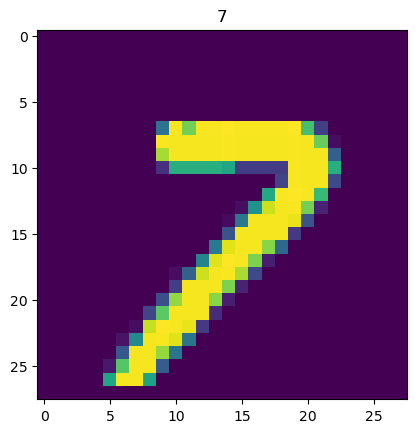

In [31]:
import matplotlib.pyplot as plt
plt.title(f"{targets[0]}")
plt.imshow(inputs[0,0])
plt.show()